In [18]:
!pip install xgboost lightgbm scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import lightgbm as lgb

import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("../data/raw/sales_data.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [21]:
for col in df.columns:
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
City
State
Country
Postal Code
Market
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit
Shipping Cost
Order Priority


In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["month"] = df["Order Date"].dt.month
df["day_of_week"] = df["Order Date"].dt.dayofweek

C:\Users\marth\AppData\Local\Temp\ipykernel_28456\3657086324.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [42]:
features = [
    "price",
    "Discount",
    "Shipping Cost",
    "month",
    "day_of_week"
]
X = df[features]
y = df["Quantity"]

In [43]:
df["price"] = df["Sales"] / df["Quantity"]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [45]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [12]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 557
[LightGBM] [Info] Number of data points in the train set: 41032, number of used features: 5
[LightGBM] [Info] Start training from score 3.476433
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    
    print(name)
    
    print("MAE:", mean_absolute_error(y_true, y_pred))
    
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    
    print("R2:", r2_score(y_true, y_pred))
    
    print()

evaluate(y_test, xgb_pred, "XGBoost")

evaluate(y_test, lgb_pred, "LightGBM")

XGBoost
MAE: 1.203629732131958
RMSE: 1.649029376904722
R2: 0.46819978952407837

LightGBM
MAE: 1.5209585790286921
RMSE: 2.004382033967593
R2: 0.21430718515087677



In [35]:
price_multipliers = [0.9, 1.0, 1.1]

revenues = []

for m in price_multipliers:

    temp = X_test.copy()

    temp["Sales"] = temp["Sales"] * m

    predicted_demand = xgb_model.predict(temp)

    revenue = (temp["Sales"] * predicted_demand).sum()

    revenues.append(revenue)

revenues

[np.float64(11061568.251120161),
 np.float64(12548782.895651601),
 np.float64(14158835.176068006)]

In [47]:
static_revenue = df["Sales"].sum()

In [48]:
ml_revenue = max(revenues)

In [49]:
revenue_lift = ((ml_revenue - static_revenue) / static_revenue) * 100

print("Static Revenue:", static_revenue)
print("ML Revenue:", ml_revenue)
print("Revenue Lift:", revenue_lift,"%")

Static Revenue: 12642501.909880001
ML Revenue: 14158835.176068006
Revenue Lift: 11.993933455552847 %


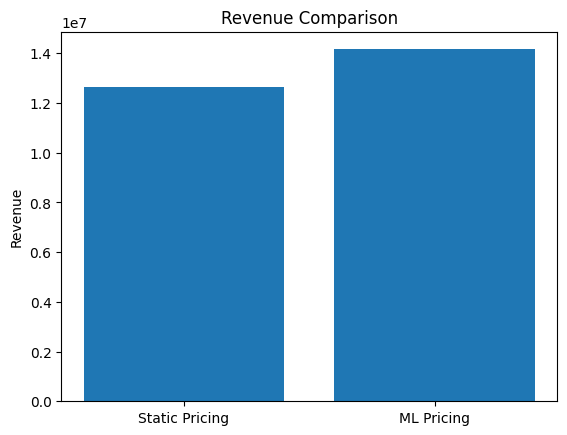

In [50]:
import matplotlib.pyplot as plt

labels = ["Static Pricing", "ML Pricing"]
values = [static_revenue, ml_revenue]

plt.bar(labels, values)
plt.title("Revenue Comparison")
plt.ylabel("Revenue")

plt.show()